In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import tensorflow as tf
from tensorflow.keras import datasets, layers, models

import tensorflow_datasets as tfds

In [2]:
ds, ds_info = tfds.load('food101', shuffle_files=True, as_supervised=True, with_info=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.KWCTKS_2.0.0/food101-train.tfrecord-[0-9][0-9][0-9][0-9…

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.KWCTKS_2.0.0/food101-validation.tfrecord-[0-9][0-9][0-9…

Dataset food101 downloaded and prepared to /root/tensorflow_datasets/food101/2.0.0. Subsequent calls will reuse this data.


In [3]:
train_ds, valid_ds = ds["train"], ds["validation"]

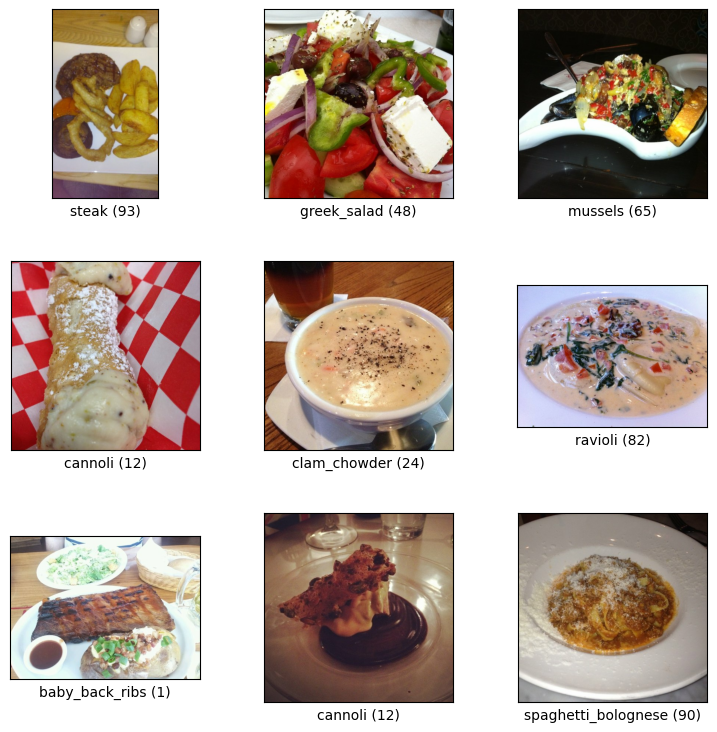

In [4]:
fig = tfds.show_examples(train_ds, ds_info)

In [5]:
MAX_SIDE_LEN = 128
HOT_DOG_CLASS = 55
train_ds = train_ds.map(
    lambda image, label: (tf.cast(tf.image.resize(image, [MAX_SIDE_LEN, MAX_SIDE_LEN]), dtype=tf.int32), tf.cast(label == HOT_DOG_CLASS, dtype=tf.int32))
)
valid_ds = valid_ds.map(
    lambda image, label: (tf.cast(tf.image.resize(image, [MAX_SIDE_LEN, MAX_SIDE_LEN]), dtype=tf.int32), tf.cast(label == HOT_DOG_CLASS, dtype=tf.int32))
)

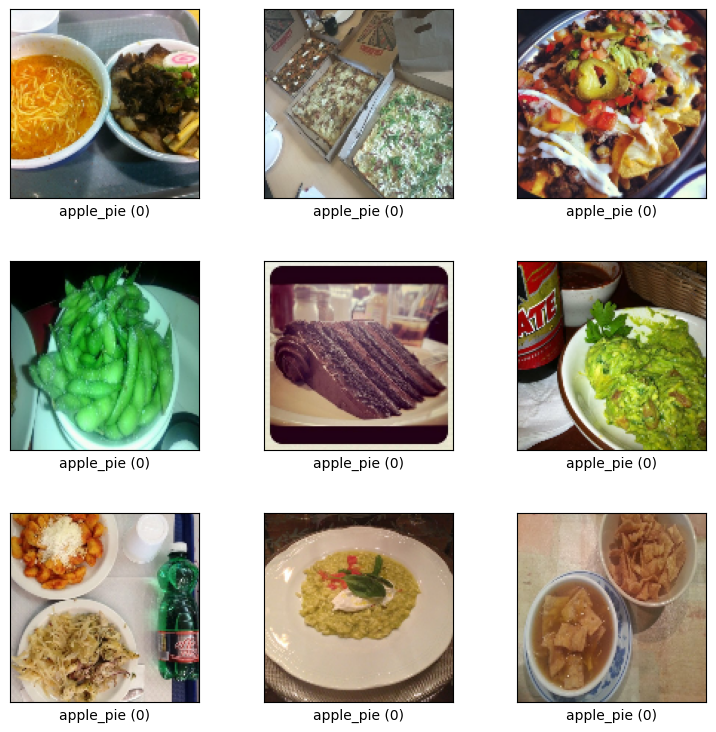

In [6]:
fig = tfds.show_examples(train_ds, ds_info)

In [7]:
train_hd_size, valid_hd_size = 750, 250
train_hotdogs = train_ds.filter(lambda _, label: label == 1).repeat(3)
train_nothotdogs = train_ds.filter(lambda _, label: label == 0)

In [8]:
valid_hotdogs = valid_ds.filter(lambda _, label: label == 1).repeat(3)
valid_nothotdogs = valid_ds.filter(lambda _, label: label == 0)

In [9]:
batch_size = 16
train_ds = tf.data.Dataset.sample_from_datasets([train_hotdogs, train_nothotdogs], weights=[0.5, 0.5], stop_on_empty_dataset=True)
train_ds = train_ds.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)

valid_ds = tf.data.Dataset.sample_from_datasets([valid_hotdogs, valid_nothotdogs], weights=[0.5, 0.5], stop_on_empty_dataset=True)
valid_ds = valid_ds.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [10]:
for image, label in train_ds.take(3):
  print(image[0][0][0])
  print(label)

tf.Tensor([253 255 254], shape=(3,), dtype=int32)
tf.Tensor([1 0 0 1 0 0 1 0 1 1 1 1 1 0 1 1], shape=(16,), dtype=int32)
tf.Tensor([80 76 58], shape=(3,), dtype=int32)
tf.Tensor([0 0 0 0 0 1 1 0 1 0 1 1 1 0 0 1], shape=(16,), dtype=int32)
tf.Tensor([155 150 147], shape=(3,), dtype=int32)
tf.Tensor([1 0 1 1 0 0 0 1 1 0 1 0 1 1 1 1], shape=(16,), dtype=int32)


In [11]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal'),
  tf.keras.layers.RandomRotation(0.2),
])

In [12]:
random.seed(0)
model = models.Sequential()
model.add(layers.Rescaling(1./255))
model.add(layers.Conv2D(128, (3, 3), activation='relu', input_shape=(MAX_SIDE_LEN, MAX_SIDE_LEN, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.25))
model.add(layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2=0.01)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.25))
model.add(layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(l2=0.01)))
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.25))
model.add(layers.Dense(1))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
lr = 0.0001
model.compile(optimizer=tf.keras.optimizers.Adam(lr),
              loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [14]:
epochs=10
history = model.fit(
  train_ds,
  validation_data=valid_ds,
  epochs=epochs,
  verbose=1
)

Epoch 1/10
    282/Unknown 308s 1s/step - accuracy: 0.4914 - loss: 1.7318

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


282/282 ━━━━━━━━━━━━━━━━━━━━ 407s 1s/step - accuracy: 0.5160 - loss: 1.5351 - val_accuracy: 0.6136 - val_loss: 1.2607
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.5595 - loss: 1.0623 - val_accuracy: 0.6503 - val_loss: 0.9785
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.5944 - loss: 0.8803 - val_accuracy: 0.7007 - val_loss: 0.8386
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.6279 - loss: 0.7890 - val_accuracy: 0.7112 - val_loss: 0.7711
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.6568 - loss: 0.7296 - val_accuracy: 0.7125 - val_loss: 0.7308
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.6828 - loss: 0.6825 - val_accuracy: 0.7164 - val_loss: 0.7163
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.7166 - loss: 0.6333 - val_accuracy: 0.7105 - val_loss: 0.6967
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.7521 - loss: 0.5820 - val_accuracy: 0.703

In [15]:
plt.figure(figsize=(10, 10))
for image_batch, label_batch in valid_ds.take(1):
  images = image_batch
  labels = label_batch

<Figure size 1000x1000 with 0 Axes>

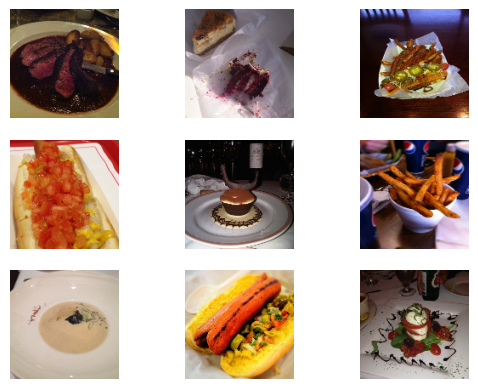

In [16]:
for i in range(9):
  ax = plt.subplot(3, 3, i+1)
  plt.imshow(images[i])
  plt.axis("off")

In [17]:
labels[:9]

<tf.Tensor: shape=(9,), dtype=int32, numpy=array([0, 0, 1, 1, 0, 0, 0, 1, 0], dtype=int32)>

In [18]:
model.save("food101_model.keras")

In [19]:
from google.colab import files

files.download("food101_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>